In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from WBUtiles.WBClean import clean_wb_wide
from WBUtiles.WBSummary import summary_wb, plot_missing_heatmap
from WBUtiles.WBLatex import make_lookup_latex, make_summary_latex

sns.set_theme(
    style="whitegrid",     # clean academic look
    context="paper",       # scales text for papers
    font_scale=1.1
)

# Data Cleaning

In [3]:
international_link = pd.read_csv('../../data/Zambia_International Linkages/international_link.csv')

In [4]:
int_link_clean, int_link_lookup = clean_wb_wide(international_link, drop_top_rows=0)

In [5]:
print(
    make_lookup_latex(
        int_link_lookup,
        caption='World Bank indicators used in International Linkages Analysis',
        label='tab:int_link_indicator_list'
    )
)

\begin{table}
\caption{World Bank indicators used in International Linkages Analysis}
\label{tab:int_link_indicator_list}
\begin{tabular}{lp{10cm}}
\toprule
Series Code & Series Name \\
\midrule
NE.EXP.GNFS.ZS & Exports of goods and services (\% of GDP) \\
NE.EXP.GNFS.KD.ZG & Exports of goods and services (annual \% growth) \\
NE.EXP.GNFS.KD & Exports of goods and services (constant 2015 US\$) \\
NE.IMP.GNFS.ZS & Imports of goods and services (\% of GDP) \\
NE.IMP.GNFS.KD.ZG & Imports of goods and services (annual \% growth) \\
NE.IMP.GNFS.KD & Imports of goods and services (constant 2015 US\$) \\
BX.KLT.DINV.WD.GD.ZS & Foreign direct investment, net inflows (\% of GDP) \\
BM.KLT.DINV.WD.GD.ZS & Foreign direct investment, net outflows (\% of GDP) \\
BX.TRF.PWKR.DT.GD.ZS & Personal remittances, received (\% of GDP) \\
DC.ODA.TOTL.GN.ZS & Net ODA provided, total (\% of GNI) \\
DT.ODA.ODAT.GN.ZS & Net ODA received (\% of GNI) \\
DT.ODA.ODAT.XP.ZS & Net ODA received (\% of central governme

# Check Data Availability

In [6]:
int_link_summary = summary_wb(int_link_clean, int_link_lookup)
int_link_summary

,Series Code,Series Name,missing_pct,n_obs,first_year,last_year
0,NE.EXP.GNFS.ZS,Exports of goods and services (% of GDP),52.307692,31,1994.0,2024.0
1,NE.EXP.GNFS.KD.ZG,Exports of goods and services (annual % growth),23.076923,50,1961.0,2010.0
2,NE.EXP.GNFS.KD,Exports of goods and services (constant 2015 US$),98.461538,1,2015.0,2015.0
3,NE.IMP.GNFS.ZS,Imports of goods and services (% of GDP),52.307692,31,1994.0,2024.0
4,NE.IMP.GNFS.KD.ZG,Imports of goods and services (annual % growth),23.076923,50,1961.0,2010.0
5,NE.IMP.GNFS.KD,Imports of goods and services (constant 2015 US$),98.461538,1,2015.0,2015.0
6,BX.KLT.DINV.WD.GD.ZS,"Foreign direct investment, net inflows (% of GDP)",15.384615,55,1970.0,2024.0
7,BM.KLT.DINV.WD.GD.ZS,"Foreign direct investment, net outflows (% of ...",27.692308,47,1978.0,2024.0
8,BX.TRF.PWKR.DT.GD.ZS,"Personal remittances, received (% of GDP)",66.153846,22,2003.0,2024.0
9,DC.ODA.TOTL.GN.ZS,"Net ODA provided, total (% of GNI)",100.000000,0,NaN,NaN


In [7]:
print(
    make_summary_latex(
    int_link_summary,
    caption='Data availability of International Linkages (Zambia)',
    label='tab:int_link_data_availability')
)

\begin{table}
\caption{Data availability of International Linkages (Zambia)}
\label{tab:int_link_data_availability}
\begin{tabular}{lrrrr}
\toprule
Series Code & Missing (\textbackslash \%) & Obs. & First year & Last year \\
\midrule
NE.EXP.GNFS.ZS & 52.30 & 31 & 1994.00 & 2024.00 \\
NE.EXP.GNFS.KD.ZG & 23.10 & 50 & 1961.00 & 2010.00 \\
NE.EXP.GNFS.KD & 98.50 & 1 & 2015.00 & 2015.00 \\
NE.IMP.GNFS.ZS & 52.30 & 31 & 1994.00 & 2024.00 \\
NE.IMP.GNFS.KD.ZG & 23.10 & 50 & 1961.00 & 2010.00 \\
NE.IMP.GNFS.KD & 98.50 & 1 & 2015.00 & 2015.00 \\
BX.KLT.DINV.WD.GD.ZS & 15.40 & 55 & 1970.00 & 2024.00 \\
BM.KLT.DINV.WD.GD.ZS & 27.70 & 47 & 1978.00 & 2024.00 \\
BX.TRF.PWKR.DT.GD.ZS & 66.20 & 22 & 2003.00 & 2024.00 \\
DC.ODA.TOTL.GN.ZS & 100.00 & 0 & NaN & NaN \\
DT.ODA.ODAT.GN.ZS & 1.50 & 64 & 1960.00 & 2023.00 \\
DT.ODA.ODAT.XP.ZS & 64.60 & 23 & 1998.00 & 2021.00 \\
DT.ODA.ODAT.PC.ZS & 1.50 & 64 & 1960.00 & 2023.00 \\
\bottomrule
\end{tabular}
\end{table}



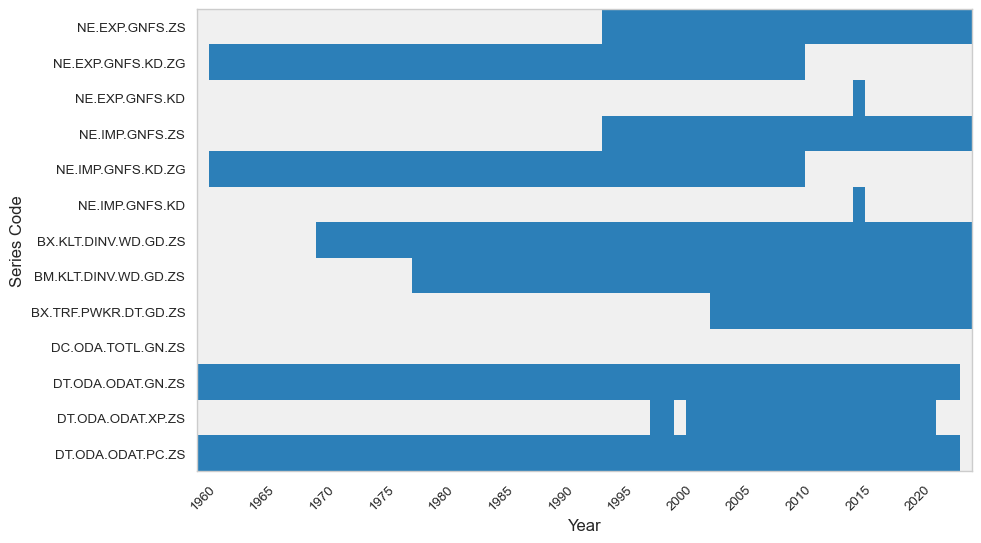

In [8]:
availability, fig, ax = plot_missing_heatmap(
    int_link_clean,
    lookup=int_link_lookup
)

# Data Visualization

In [9]:
int_link_lookup

,Series Code,Series Name
0,NE.EXP.GNFS.ZS,Exports of goods and services (% of GDP)
1,NE.EXP.GNFS.KD.ZG,Exports of goods and services (annual % growth)
2,NE.EXP.GNFS.KD,Exports of goods and services (constant 2015 US$)
3,NE.IMP.GNFS.ZS,Imports of goods and services (% of GDP)
4,NE.IMP.GNFS.KD.ZG,Imports of goods and services (annual % growth)
5,NE.IMP.GNFS.KD,Imports of goods and services (constant 2015 US$)
6,BX.KLT.DINV.WD.GD.ZS,"Foreign direct investment, net inflows (% of GDP)"
7,BM.KLT.DINV.WD.GD.ZS,"Foreign direct investment, net outflows (% of ..."
8,BX.TRF.PWKR.DT.GD.ZS,"Personal remittances, received (% of GDP)"
9,DC.ODA.TOTL.GN.ZS,"Net ODA provided, total (% of GNI)"


## International Trade

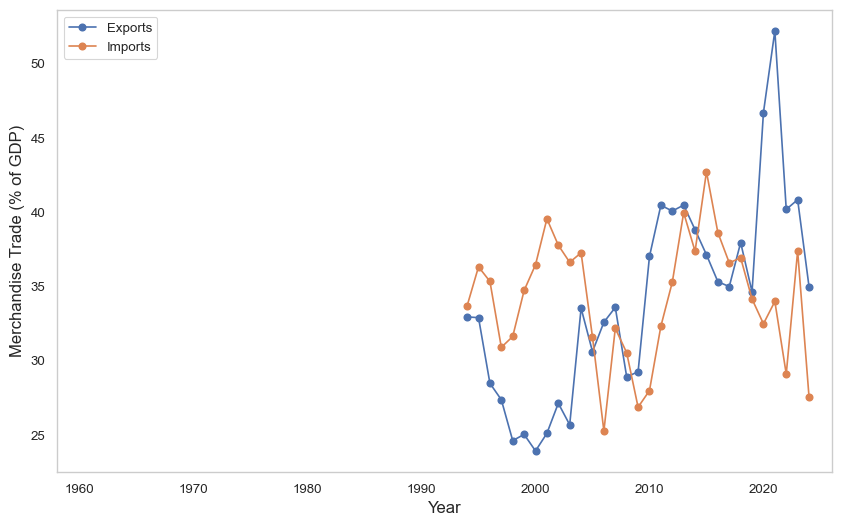

In [20]:
# merchandise exports and import (as percentage of GDP) NE.EXP.GNFS.ZS, NE.IMP.GNFS.ZS
df = int_link_clean.dropna(subset=['NE.EXP.GNFS.ZS', 'NE.IMP.GNFS.ZS'])
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(df['Year'], df['NE.EXP.GNFS.ZS'], marker='o', label='Exports')
ax.plot(df['Year'], df['NE.IMP.GNFS.ZS'], marker='o', label='Imports')
ax.legend()

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Merchandise Trade (% of GDP)', fontsize=12)
ax.set_xlim(1958, 2026)
ax.grid(False)

fig.savefig(
    "../figures/Zambia/int_link/merchandise_trade.pdf",
    format="pdf",
    bbox_inches="tight"
)

- **structure of merchandise exports**
    - food commodities (SITC section 0, 1, 2, 4)
    - fuels (SITC section 3)
    - machinery (SITC section 7)
    - other manufactures (SITC section 5, 6, 8, 9)
- **structure of merchandise imports**

## International Investment

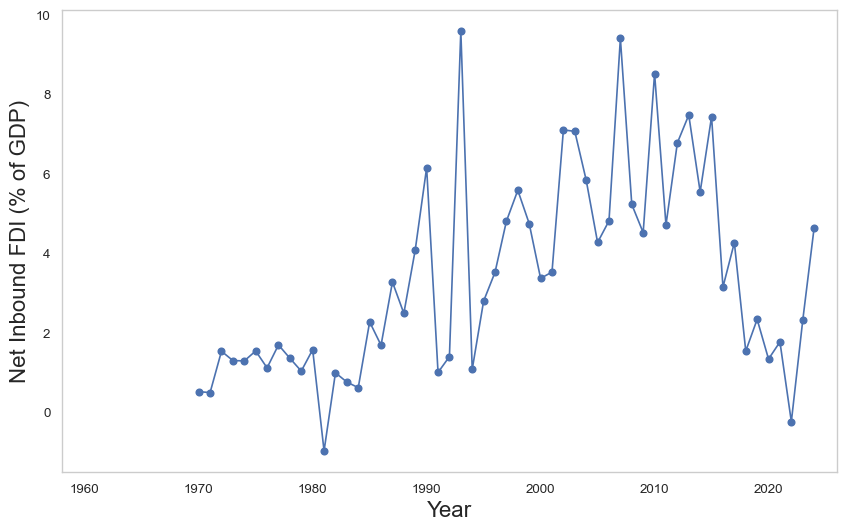

In [19]:
# Inbound FDI, net (percentage of GDP) BX.KLT.DINV.WD.GD.ZS (inflow)
df = int_link_clean.dropna(subset=['BX.KLT.DINV.WD.GD.ZS'])
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(df['Year'], df['BX.KLT.DINV.WD.GD.ZS'], marker='o')

ax.set_xlabel('Year', fontsize=16)
ax.set_ylabel('Net Inbound FDI (% of GDP)', fontsize=16)

ax.set_xlim(1958, 2026)
ax.grid(False)

fig.savefig(
    "../figures/Zambia/int_link/inbound_fdi.pdf",
    format="pdf",
    bbox_inches="tight"
)

## Private International Transfers

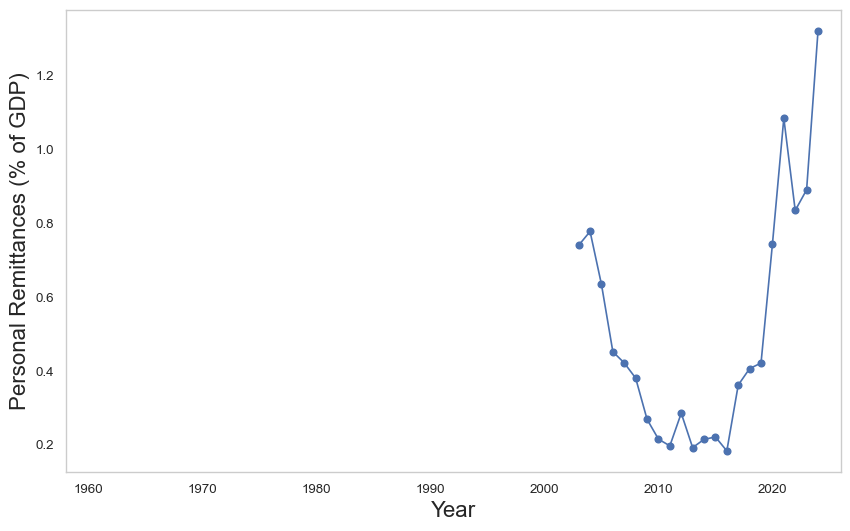

In [18]:
# Remittances (percentage of GDP) BX.TRF.PWKR.DT.GD.ZS
df = int_link_clean.dropna(subset=['BX.TRF.PWKR.DT.GD.ZS'])
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(df['Year'], df['BX.TRF.PWKR.DT.GD.ZS'], marker='o')

ax.set_xlabel('Year', fontsize=16)
ax.set_ylabel('Personal Remittances (% of GDP)', fontsize=16)

ax.set_xlim(1958, 2026)
ax.grid(False)

fig.savefig(
    "../figures/Zambia/int_link/remittances.pdf",
    format="pdf",
    bbox_inches="tight"
)

## Official International Transfers

In [13]:
# official development assistance: total receipts (percentage of GNI) DC.ODA.TOTL.GN.ZS
df = int_link_clean.dropna(subset=['DC.ODA.TOTL.GN.ZS'])
df['DC.ODA.TOTL.GN.ZS'].describe()

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: DC.ODA.TOTL.GN.ZS, dtype: float64